Shows how to detrend the MBES data such that you can see the local variations eg rock or bombs


In [ ]:
import sys, os

sys.path.append(os.path.abspath("../"))
from utils.other.detrend_mbes import MBESDetrender, AutoTuneMBES, ScoreWeights
from gref_pipeline import config
import matplotlib.pyplot as plt

plt.ion()

In [ ]:
tif_path = config.MBES_GEOTIFF


manually tune the parameters

## Option 2: NED coordinates (local frame, relative to origin)
Plots will show coordinates relative to the NED origin from config

c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\other\detrend_mbes.py:633: UserWarning: Could not import config module for UHI footprint defaults. Skipping UHI footprint loading.
  warnings.warn(


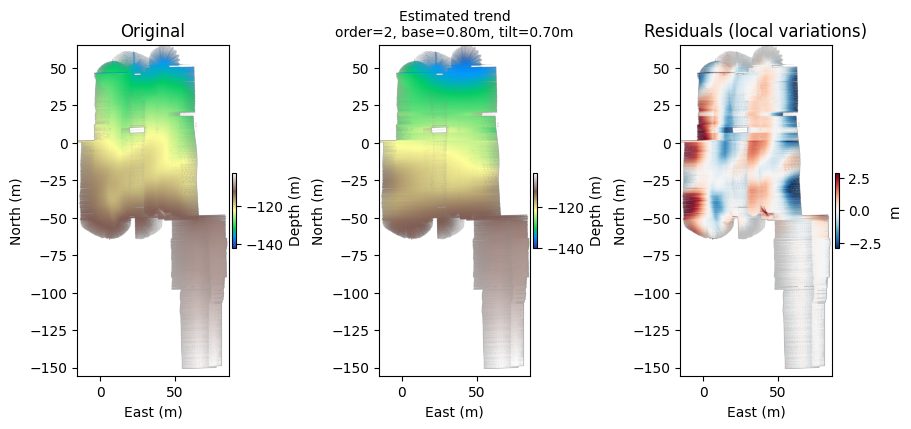

✅ Done! UHI footprint loaded automatically and displayed as black outline.


In [ ]:
# Simplified! UHI footprint is now loaded automatically in load()
# Just create the MBESDetrender and plot with footprint_style
mb_ned = (
    MBESDetrender(
        tif_path,
        coord_system="ned",
        ned_origin=(config.LON0, config.LAT0, config.H0),
        epsg_utm=config.EPSG_UTM,
        epsg_geo=config.EPSG_GEOGRAPHIC,
    )
    .load()  # Automatically loads UHI footprint using config defaults
    .detrend(
        order_x=3,
        smooth_baseline_m=0.80,
        smooth_tilt_m=0.70,
        smooth_center_m=1.0,
        robust=True,
        central_frac=0.8,
    )
)

# Plot with UHI footprint overlay - that's it!
fig = mb_ned.plot_triptych(footprint_style="outline", show=True)
print("✅ Done! UHI footprint loaded automatically and displayed as black outline.")

In [ ]:
# stop

In [ ]:
# NEW: Zoomed-in view of MBES residuals within UHI footprint
# This creates a separate figure showing only the area inside the UHI footprint
fig_zoomed = mb_ned.plot_zoomed_residuals(
    outline_color="black", outline_width=1.2, cmap="RdBu_r", figsize=(9, 11), show=True
)
print("✅ Zoomed residuals plot created!")

ValueError: plot_zoomed_residuals() requires UHI footprint data. Ensure UHI footprint was loaded during .load() or provide manually.

In [ ]:
# Test with z-scores (default - typical range -6 to +6)
mb_ned.adjust_uhi_alignment(dx=-0.05, dy=-3)

✅ UHI footprint adjusted: dx=-0.050m E, dy=-3.000m N


MBESDetrender(tif_path='E:\\mjosa_new\\DTM\\geotiff_2.tif', nodata_value=9999.0, coord_system='ned', ned_origin=(10.705125, 60.801146, 0.0), epsg_utm=32632, epsg_geo=4326, smooth_baseline_m=0.8, smooth_tilt_m=0.7, smooth_curv_m=0.7, smooth_center_m=1.0, max_row_iters=3, clip_sigma=6.0, central_frac=0.8, uhi_transect_folder=None, uhi_files=None, uhi_track_range=None, data=array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]]), valid_mask=array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, Fals

In [ ]:
%matplotlib qt
fig1 = mb_ned.plot_uhi_mbes_comparison(
    use_adjusted=True, normalization_method="zscore", show=True
)

In [ ]:
%matplotlib qt
fig1 = mb_ned.plot_uhi_mbes_comparison(
    use_adjusted=True, normalization_method="minmax", show=True
)

🔄 Loading UHI cube data (first time only)...
✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 2 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
✅ Loaded illumination correction from disk
✅ UHI cube cached! Subsequent calls will reuse this data.
✅ UHI cube cached! Subsequent calls will reuse this data.


In [ ]:
fig_scatter1 = mb_ned.plot_density_scatter(
    use_adjusted=True, normalization_method="zscore", show=True, figsize=(4, 4)
)


=== DENSITY SCATTER DEBUG ===
flip_uhi_sign: False
normalization_method: zscore
inside.shape: (5249, 1408), inside.sum(): 56393
mbes_in.shape: (5249, 1408), finite: 56390
uhi_in.shape: (5249, 1408), finite: 56393
mbes_in range: [-0.0647, 0.4278]
uhi_in range: [0.7670, 11548.0234]
After zscore (on paired samples only):
z_mbes range: [-3.5473, 22.5895]
z_uhi range: [-5.3376, 191108.1472]
z_mbes median: 0.0000, std: 1.4439
z_uhi median: 0.0000, std: 1992.0385



In [ ]:
fig = mb_ned.plot_triptych(footprint_style="outline", show=True, use_adjusted=True)

In [ ]:
fig_scatter2 = mb_ned.plot_density_scatter(
    use_adjusted=True, normalization_method="minmax", show=True
)

NameError: name 'mb_ned' is not defined

### Alternative: Generate All Plots at Once

You can also use `plot_all()` to generate all visualizations in one call, including the UHI comparison plots:

In [ ]:
stop

In [ ]:
# Generate all plots at once (basic + UHI comparison)
# Returns tuple of figures: (triptych, components, heatmap, comparison, scatter)
all_figs = mb_ned.plot_all(show=True, include_uhi_comparison=False)
print(f"✅ Generated {len(all_figs)} figures total!")

✅ Generated 3 figures total!


# uses a autotuner to find optimal parameters

In [ ]:
stop run all 

SyntaxError: invalid syntax (2350569927.py, line 1)

### Autotuner Parameter Guide

**Problem:** Default autotuner does 162 iterations (round 1) + 625 iterations (round 2) = **787 total!**

**Solutions to reduce iterations:**

1. **Set `max_rounds=1`** - Skip the refinement round
   - Round 1 only: **162 iterations** (coarse grid search)
   
2. **Use `allowed_orders=(3,)`** - Fix the polynomial order
   - Reduces round 1 to **81 iterations** (only order 3)
   - Reduces round 2 to **625 iterations** (if used)
   
3. **Increase `row_stride` and `col_stride`**
   - Default: `(4, 4)` - samples every 4th pixel
   - Try: `(8, 8)` or `(10, 10)` - **faster evaluation** (same # iterations, but quicker)
   
4. **Combine strategies** for maximum speed:
   ```python
   # FAST MODE: ~81 iterations total
   tuner = AutoTuneMBES(mb_ned, 
                        allowed_orders=(3,),      # Fix order
                        row_stride=8, col_stride=8,  # Coarser sampling
                        ...)
   best = tuner.fit(max_rounds=1)  # Skip refinement
   ```

In [ ]:
# FAST MODE: Only ~81 iterations instead of 787!
tuner_fast = AutoTuneMBES(
    mb_ned,
    allowed_orders=(3,),  # Fix order to 3 (halves iterations)
    row_stride=8,  # Coarser sampling (faster per iteration)
    col_stride=8,
    weights=ScoreWeights(
        w_rstd=1.0,
        w_banding=1.0,
        w_edge_bias=3.0,
        w_x_slope=1.0,
        w_rough_B=0.3,
        w_rough_X=0.3,
    ),
    log_csv="mbes_tuning_log_fast.csv",
    progress_every=10,
)

best_fast = tuner_fast.fit(max_rounds=1, resume=True)  # Only coarse search
mb_best_fast = tuner_fast.apply_best_and_plot()

[resume] no CSV at c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\notebooks\mbes_tuning_log_fast.csv


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\other\detrend_mbes.py:590: UserWarning: UHI footprint loading requires coord_system='ned'. Skipping UHI footprint. Set coord_system='ned' and provide ned_origin.
  warnings.warn(
c:\conda_envs\my_env\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


KeyboardInterrupt: 

**SLOW MODE** (for reference - 787 iterations total):

In [ ]:
# Cell 3: optional autotune, then plot with best params
tuner = AutoTuneMBES(
    mb_ned,
    allowed_orders=(2, 3),
    row_stride=4,
    col_stride=4,  # 1,1 for max accuracy
    weights=ScoreWeights(
        w_rstd=1.0,
        w_banding=1.0,
        w_edge_bias=3.0,
        w_x_slope=1.0,
        w_rough_B=0.3,
        w_rough_X=0.3,
    ),
    log_csv="mbes_tuning_log.csv",
    progress_every=5,
)

best = tuner.fit(max_rounds=2, resume=True)
mb_best = tuner.apply_best_and_plot()

[resume] loaded 660 trials from c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\notebooks\mbes_tuning_log.csv
Coarse best: {'order': 2, 'central_frac': 0.7, 'baseline_m': 0.357, 'tilt_m': 4.05, 'center_m': 1.3439999999999999} -> 8.867409 (0.0s)
Round 1: 625 neighbors
   ... 5/625 done (best=8.8674)
   ... 5/625 done (best=8.8674)
   ... 10/625 done (best=8.8674)
   ... 10/625 done (best=8.8674)
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 0.9407999999999999}  8.382118
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 0.9407999999999999}  8.382118
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 1.3439999999999999}  8.380857
  better: {'order': 2, 'central_frac': 0.6, 'baseline_m': 0.24989999999999998, 'tilt_m': 4.05, 'center_m': 1.34399999999

In [ ]:
# tuner = AutoTuneMBES(
#     mb,
#     allowed_orders=(2, 3),
#     row_stride=4,
#     col_stride=4,
#     weights=ScoreWeights(),
#     log_csv="mbes_tuning_log.csv",
# )
# best = tuner.fit(max_rounds=2, resume=True)
# mb_best = tuner.apply_best_and_plot()

c:\conda_envs\my_env\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


... tried 35/162 (last 26.3390)


## 🔧 Fixed Density Scatter Plot

The `plot_density_scatter` function has been fixed. The issue was that normalizing each dataset separately (MBES and UHI) on their full grids created artificial correlation. 

**The Fix**: Normalization is now applied only to the paired samples (valid overlapping pixels), which preserves the true statistical relationship between the datasets.

In [ ]:
# Test the fixed version
# The correlation should now be close to 0 if MBES and UHI are truly independent
fig_scatter_fixed = mb_ned.plot_density_scatter(
    use_adjusted=True, normalization_method="zscore", show=True
)
print("✅ If r ≈ 0, the datasets are independent (as expected!)")